## コイン投げの確率分布

コインを10回投げたときに「表（Heads）」が出る回数ごとの確率分布を示したグラフです。  
横軸は「表が出た回数（0回～10回）」、縦軸はその回数が出る確率を表しています。  
この分布は「二項分布」と呼ばれ、各試行（コイン投げ）が独立で、表が出る確率が常に50%の場合に成り立ちます。  
グラフを見ると、表が5回前後出る確率が最も高く、0回や10回など極端な結果は確率が低いことがわかります。  
このような分布は、コイン投げのような「成功・失敗」が繰り返される現象の確率を直感的に理解するのに役立ちます。

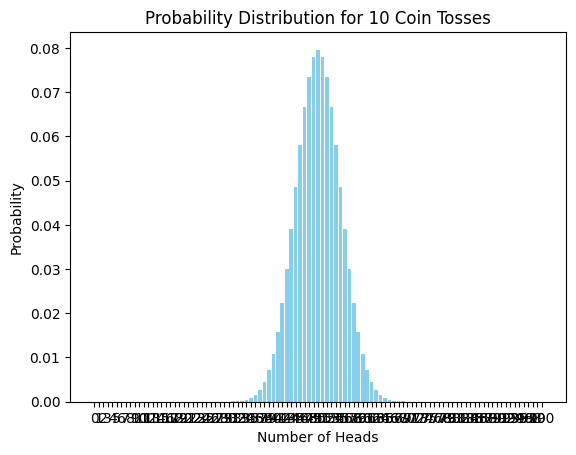

In [2]:
import numpy as np
from scipy.stats import binom

import matplotlib.pyplot as plt

n_tosses = 100
p_head = 0.5

# Possible number of heads (0 to 10)
x = np.arange(0, n_tosses + 1)
# Binomial probability mass function
probs = binom.pmf(x, n_tosses, p_head)

plt.bar(x, probs, color='skyblue')
plt.xlabel('Number of Heads')
plt.ylabel('Probability')
plt.title('Probability Distribution for 10 Coin Tosses')
plt.xticks(x)
plt.show()

# Coin Toss シミュレーター
このアプレットは、コイン投げのシミュレーションを行うものです。  

- 「Toss 1」「Toss 10」「Toss 100」のボタンを使って、それぞれ1回、10回、100回のコイン投げを実行できます。  
- 「Reset」ボタンを押すと、結果がリセットされます。

グラフには、コインを投げた回数ごとの「表（Heads）」が出た割合が表示され、50%の基準線も描かれています。  
また、下部には「表」と「裏（Tails）」の出た回数が表示されます。  
このアプレットを使うことで、コイン投げの確率やランダム性について直感的に理解することができます。

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np

import matplotlib.pyplot as plt

# State
results = []

# Buttons
button_1 = widgets.Button(description='Toss 1')
button_10 = widgets.Button(description='Toss 10')
button_100 = widgets.Button(description='Toss 100')
button_reset = widgets.Button(description='Reset', button_style='danger')
buttons = widgets.HBox([button_1, button_10, button_100, button_reset])

# Outputs
output_plot = widgets.Output()
output_data = widgets.Output()

def update_outputs():
    with output_plot:
        clear_output(wait=True)
        if not results:
            plt.figure(figsize=(8, 4))
            plt.title("Percent Heads Over Time")
            plt.xlabel("Toss Number")
            plt.ylabel("Percent Heads")
            plt.axhline(0.5, color='gray', linestyle='--', label='50%')
            plt.ylim(0, 1)
            plt.legend()
            plt.show()
            return

        heads_count = np.cumsum(np.array(results) == 'Heads')
        percent_heads = heads_count / np.arange(1, len(results) + 1)
        x_vals = np.arange(1, len(results) + 1)
        colors = ['green' if r == 'Heads' else 'red' for r in results]

        plt.figure(figsize=(10, 5))
        plt.plot(x_vals, percent_heads, color='blue', label='Percent Heads')
        plt.scatter(x_vals, percent_heads, c=colors, s=60, zorder=3)
        plt.axhline(0.5, color='gray', linestyle='--', label='50%')
        plt.xlabel("Toss Number")
        plt.ylabel("Percent Heads")
        plt.ylim(0, 1)
        plt.title("Percent Heads Over Time")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    with output_data:
        clear_output(wait=True)
        heads = results.count('Heads')
        tails = results.count('Tails')
        print(f"Heads: {heads}")
        print(f"Tails: {tails}")

def toss(n):
    for _ in range(n):
        results.append('Heads' if np.random.rand() < 0.5 else 'Tails')
    update_outputs()

def on_toss_1(b):
    toss(1)

def on_toss_10(b):
    toss(10)

def on_toss_100(b):
    toss(100)

def on_reset(b):
    results.clear()
    update_outputs()

button_1.on_click(on_toss_1)
button_10.on_click(on_toss_10)
button_100.on_click(on_toss_100)
button_reset.on_click(on_reset)

display(buttons, output_plot, output_data)
update_outputs()

Output()

Output()